# Assignment 1: MLP for House Price Prediction
## ICS3308 - Deep Learning

**Objective:** Use a Multi-Layer Perceptron (MLP) to predict house prices using the California Housing Dataset.

### Overview
This notebook demonstrates:
- Loading and exploring the California Housing Dataset
- Data preprocessing (scaling, train/test split)
- Building a baseline MLP regression model using PyTorch
- Training with early stopping
- Evaluating with MSE, MAE, and R² metrics
- **Improvement**: Feature engineering + hyperparameter tuning combined
- Final comparison of baseline vs improved model

## 1. Install and Import Dependencies

In [1]:
# Install required packages (safe for Google Colab)
!pip install torch torchvision scikit-learn matplotlib seaborn pandas numpy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load and Explore the Dataset

In [3]:
# Load the California Housing dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Median house value (in $100,000s)

print(f"Dataset shape: {df.shape}")
print(f"\nFeature descriptions:")
print(housing.DESCR[:1500])

Dataset shape: (20640, 9)

Feature descriptions:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derive

In [4]:
# Basic statistics
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0


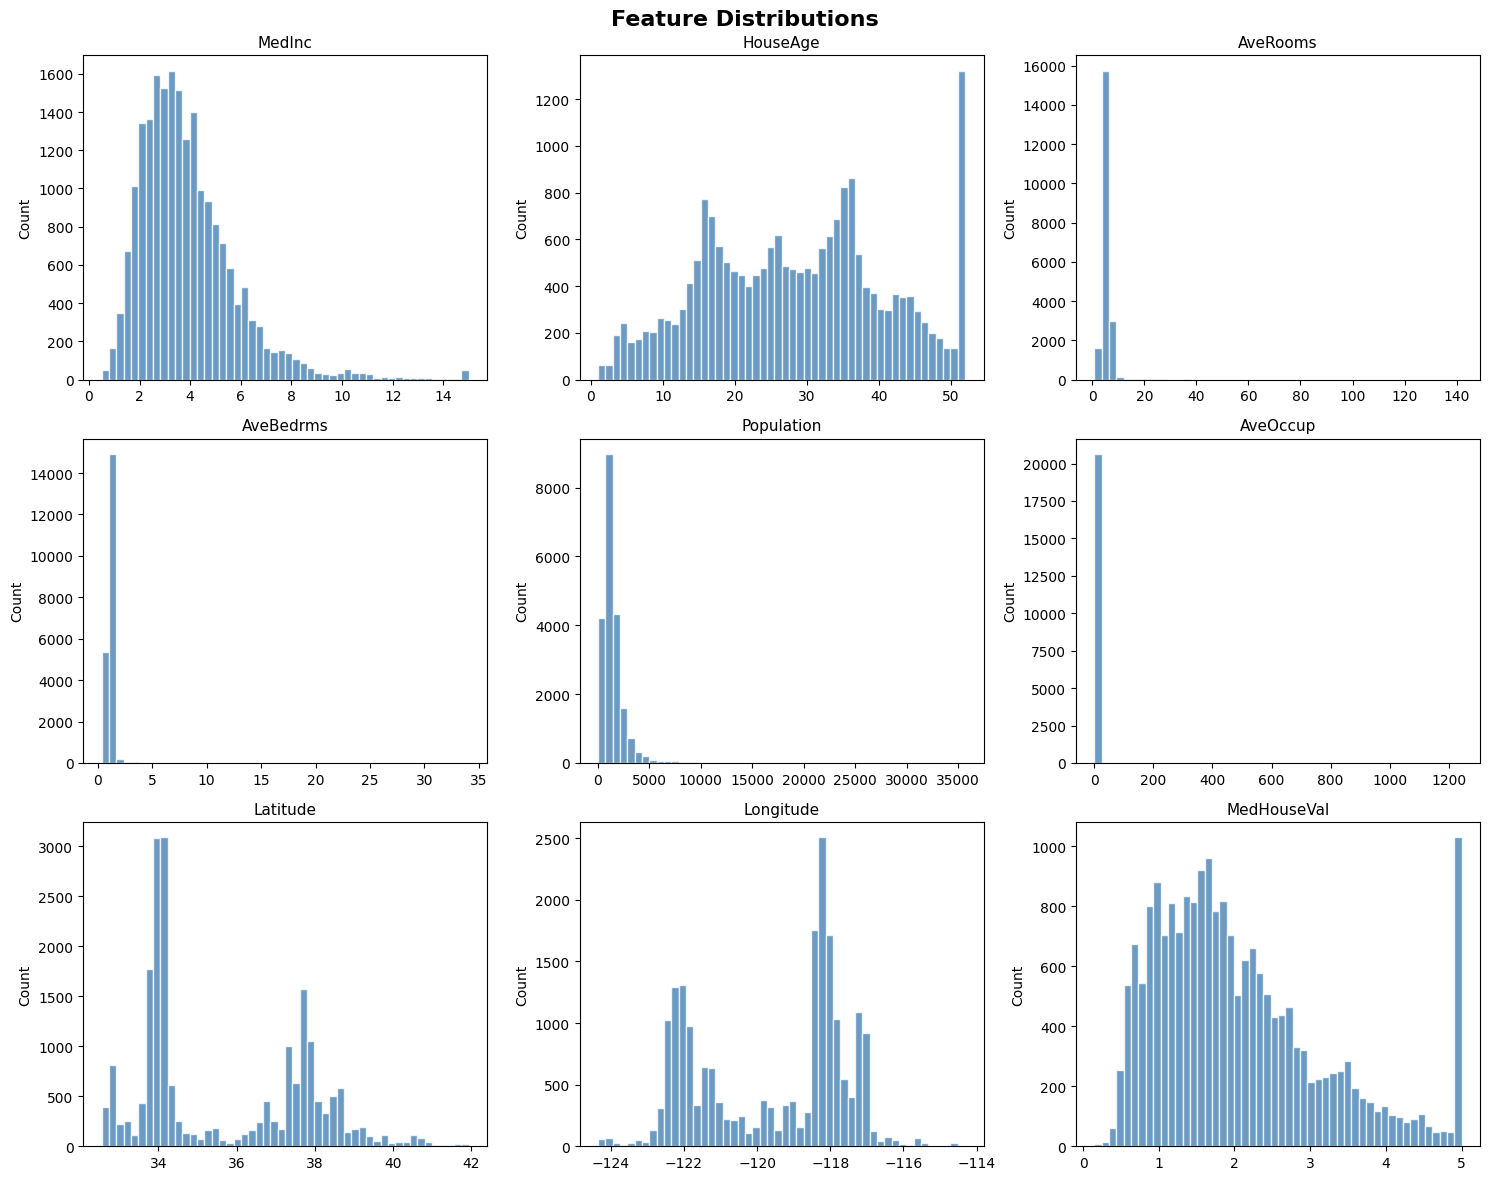

In [6]:
# Visualize feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

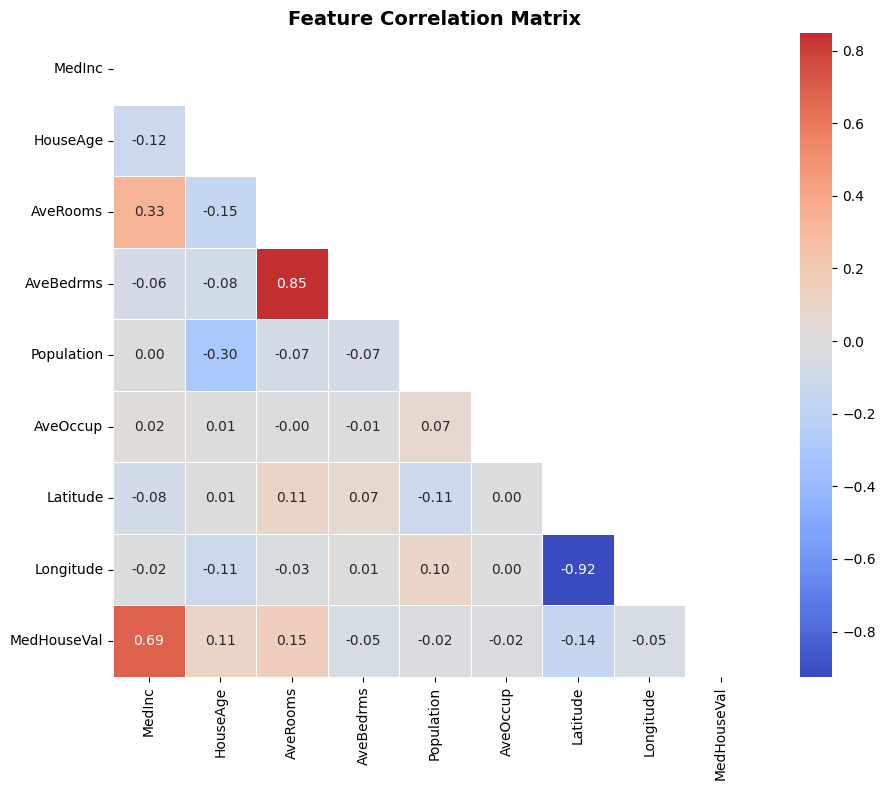

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [8]:
# Separate features and target
X = housing.data
y = housing.target

# Split into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")

Training set:   14035 samples
Validation set: 2477 samples
Test set:       4128 samples


In [9]:
# Standardize features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_val_t = torch.FloatTensor(X_val_scaled).to(device)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of features: {X_train_scaled.shape[1]}")

Number of features: 8


## 4. Define the Baseline MLP Model

In [10]:
class HousePriceMLP(nn.Module):
    """
    Multi-Layer Perceptron for house price regression.
    
    Architecture:
    - Input layer: 8 features
    - Hidden layer 1: 128 neurons + BatchNorm + ReLU + Dropout
    - Hidden layer 2: 64 neurons + BatchNorm + ReLU + Dropout
    - Hidden layer 3: 32 neurons + BatchNorm + ReLU + Dropout
    - Output layer: 1 neuron (predicted price)
    """
    def __init__(self, input_dim, dropout_rate=0.2):
        super(HousePriceMLP, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Instantiate the model
model = HousePriceMLP(input_dim=X_train_scaled.shape[1], dropout_rate=0.2).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

HousePriceMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 11,969


## 5. Training the Baseline

In [11]:
# Hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 200
PATIENCE = 20

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * X_batch.size(0)
    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            epoch_val_loss += criterion(model(X_batch), y_batch).item() * X_batch.size(0)
    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    scheduler.step(epoch_val_loss)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Patience: {patience_counter}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch [10/200] | Train Loss: 0.4411 | Val Loss: 0.7613 | Patience: 5/20
Epoch [20/200] | Train Loss: 0.3852 | Val Loss: 0.4520 | Patience: 8/20
Epoch [30/200] | Train Loss: 0.3581 | Val Loss: 0.3514 | Patience: 0/20
Epoch [40/200] | Train Loss: 0.3535 | Val Loss: 0.4222 | Patience: 2/20
Epoch [50/200] | Train Loss: 0.3458 | Val Loss: 0.6083 | Patience: 1/20
Epoch [60/200] | Train Loss: 0.3430 | Val Loss: 0.3299 | Patience: 3/20
Epoch [70/200] | Train Loss: 0.3364 | Val Loss: 0.4810 | Patience: 13/20

Early stopping triggered at epoch 77

Best validation loss: 0.2966


## 6. Training Curves

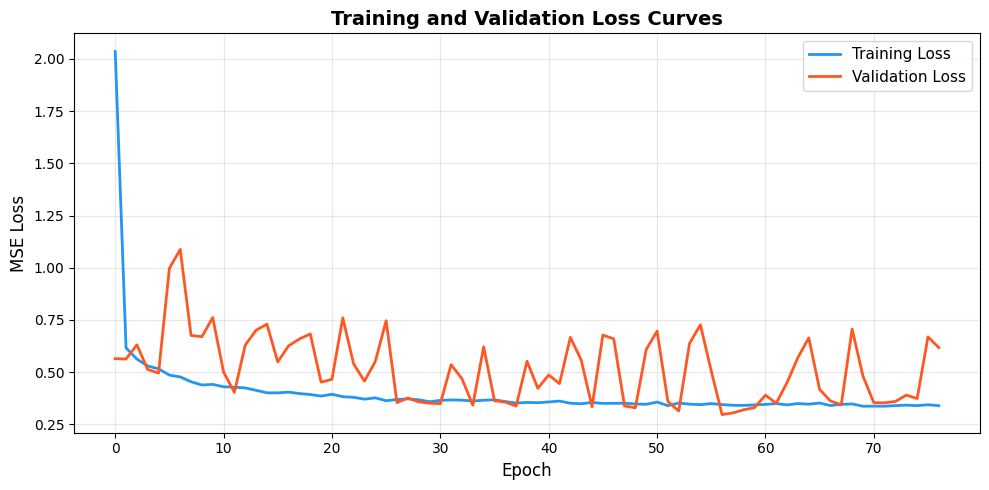

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2, color='#2196F3')
plt.plot(val_losses, label='Validation Loss', linewidth=2, color='#FF5722')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Baseline Evaluation

In [13]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        all_preds.append(model(X_batch).cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

y_pred = np.concatenate(all_preds).flatten()
y_true = np.concatenate(all_targets).flatten()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

baseline_metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('       BASELINE TEST SET RESULTS')
print('=' * 50)
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R\u00b2:   {r2:.4f}")
print('=' * 50)
print(f"\nRMSE of {rmse:.4f} means average error \u2248 ${rmse * 100000:,.0f}")

       BASELINE TEST SET RESULTS
  MSE:  0.5933
  RMSE: 0.7702
  MAE:  0.5078
  R²:   0.5473

RMSE of 0.7702 means average error ≈ $77,024


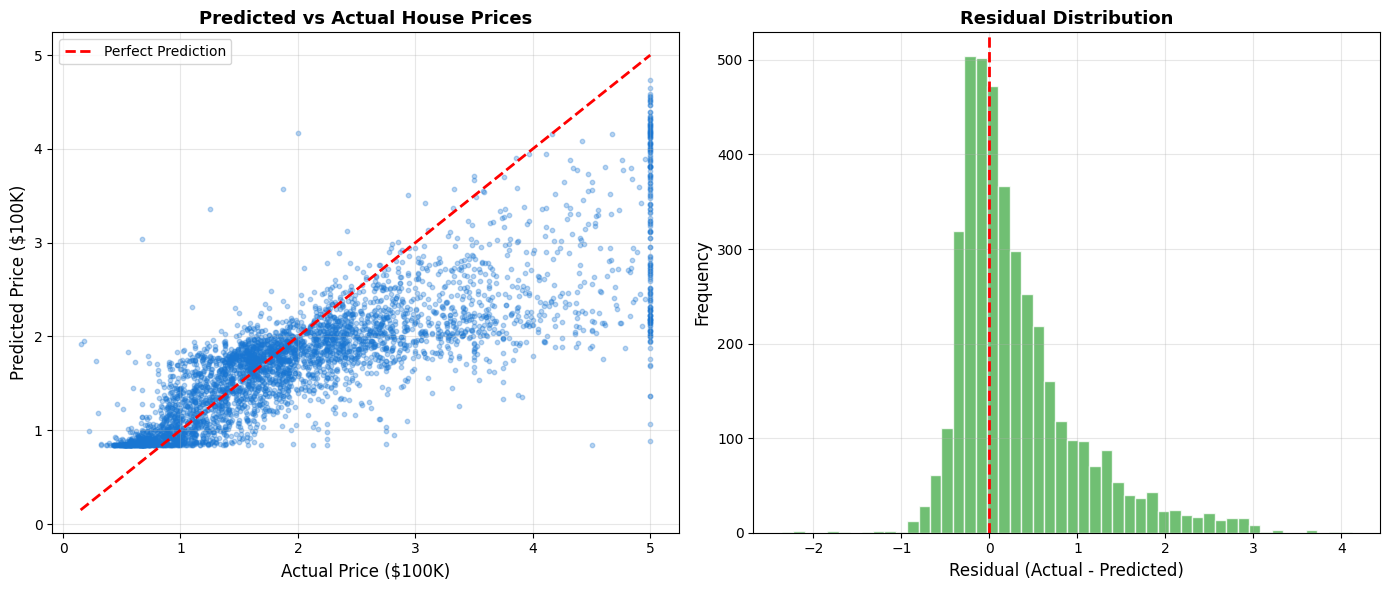

In [14]:
# Predicted vs Actual scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='#1976D2')
ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
        'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($100K)', fontsize=12)
ax.set_ylabel('Predicted Price ($100K)', fontsize=12)
ax.set_title('Predicted vs Actual House Prices', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
residuals = y_true - y_pred
ax.hist(residuals, bins=50, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residual (Actual - Predicted)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Residual Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting the Plots

**Left — Predicted vs Actual Scatter Plot:**
- Each dot represents one house in the test set. The x-axis is the true price, and the y-axis is the model's prediction.
- The red dashed line is the **perfect prediction** line (y = x). Points on this line mean the model predicted exactly right.
- Points clustered tightly around the line (low–mid price range, ~$50K–$250K) show the model is **most accurate** for typical homes.
- At the high end (~$500K), predictions flatten out and fall **below** the line — the model consistently **underestimates** expensive homes. This is partly because the dataset caps house values at $500K, so the model never learns what drives prices beyond that ceiling.

**Right — Residual Distribution:**
- A residual is `Actual − Predicted`. A perfect model would have all residuals at zero.
- The distribution is roughly **centered near zero**, confirming the model has no large systematic bias.
- The slight **right skew** (long tail toward positive residuals) reflects the underestimation of expensive homes seen in the scatter plot — for those houses, `Actual > Predicted`, producing positive residuals.
- Most residuals fall within ±$100K (±1.0 in the plot's units), meaning the majority of predictions are reasonably close.

---
# Improvement: Feature Engineering + Hyperparameter Tuning

We now combine two improvements to push beyond the baseline:

**1. Feature Engineering** — expand the 8 raw features into richer representations:
- **Squared terms** (e.g., `MedInc²`) capture non-linear effects like diminishing returns
- **Interaction terms** (e.g., `MedInc × AveRooms`) capture combined effects that the MLP would otherwise need to discover on its own

**2. Hyperparameter Tuning** — search over learning rates, architectures, and dropout rates to find the best model for these enriched features.

By combining both, the model gets better data **and** a better architecture.

### 8a. Feature Engineering

In [15]:
# Reload raw data for a clean start
X_raw = housing.data
y_raw = housing.target

# Same splits (same random_state) as baseline
X_tr_raw, X_te_raw, y_tr_fe, y_te_fe = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42)
X_tr_raw, X_va_raw, y_tr_fe, y_va_fe = train_test_split(
    X_tr_raw, y_tr_fe, test_size=0.15, random_state=42)

# Generate polynomial + interaction features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly.fit_transform(X_tr_raw)
X_va_poly = poly.transform(X_va_raw)
X_te_poly = poly.transform(X_te_raw)

n_original = X_tr_raw.shape[1]
n_poly = X_tr_poly.shape[1]

print(f'Original features:   {n_original}')
print(f'Engineered features: {n_poly}')
print(f'  ({n_original} original + {n_original} squared + '
      f'{n_poly - 2*n_original} interaction terms)')

feat_names = poly.get_feature_names_out(housing.feature_names)
print(f'\nSample engineered features:')
for name in feat_names[n_original:n_original+10]:
    print(f'  \u2022 {name}')

Original features:   8
Engineered features: 44
  (8 original + 8 squared + 28 interaction terms)

Sample engineered features:
  • MedInc^2
  • MedInc HouseAge
  • MedInc AveRooms
  • MedInc AveBedrms
  • MedInc Population
  • MedInc AveOccup
  • MedInc Latitude
  • MedInc Longitude
  • HouseAge^2
  • HouseAge AveRooms


In [16]:
# Standardize and create DataLoaders
scaler_fe = StandardScaler()
X_tr_poly = scaler_fe.fit_transform(X_tr_poly)
X_va_poly = scaler_fe.transform(X_va_poly)
X_te_poly = scaler_fe.transform(X_te_poly)

train_loader_fe = DataLoader(
    TensorDataset(torch.FloatTensor(X_tr_poly).to(device),
                  torch.FloatTensor(y_tr_fe).unsqueeze(1).to(device)),
    batch_size=BATCH_SIZE, shuffle=True)
val_loader_fe = DataLoader(
    TensorDataset(torch.FloatTensor(X_va_poly).to(device),
                  torch.FloatTensor(y_va_fe).unsqueeze(1).to(device)),
    batch_size=BATCH_SIZE, shuffle=False)
test_loader_fe = DataLoader(
    TensorDataset(torch.FloatTensor(X_te_poly).to(device),
                  torch.FloatTensor(y_te_fe).unsqueeze(1).to(device)),
    batch_size=BATCH_SIZE, shuffle=False)

print(f'DataLoaders ready with {n_poly} features.')

DataLoaders ready with 44 features.


### 8b. Flexible MLP + Hyperparameter Search

In [17]:
class FlexibleMLP(nn.Module):
    """
    MLP with configurable hidden layer sizes for hyperparameter search.
    """
    def __init__(self, input_dim, hidden_layers, dropout_rate=0.2):
        super(FlexibleMLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_layers:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

print('FlexibleMLP defined.')

FlexibleMLP defined.


In [18]:
# Define search space
search_space = {
    'lr':            [0.01, 0.001, 0.0005],
    'hidden_layers': [[256, 128, 64],
                      [128, 64, 32],
                      [512, 256, 128, 64]],
    'dropout':       [0.1, 0.2, 0.3]
}

SEARCH_EPOCHS = 80
SEARCH_PATIENCE = 15
total_combos = (len(search_space['lr']) *
                len(search_space['hidden_layers']) *
                len(search_space['dropout']))

print(f'Grid search: {total_combos} configs \u00d7 {SEARCH_EPOCHS} max epochs on {n_poly} features')
print('=' * 90)

combined_results = []
t0 = time.time()

for combo_idx, (lr, h_layers, drop) in enumerate(
    itertools.product(search_space['lr'],
                      search_space['hidden_layers'],
                      search_space['dropout'])):

    arch_str = ' \u2192 '.join(str(h) for h in h_layers)

    torch.manual_seed(42)
    m = FlexibleMLP(input_dim=n_poly, hidden_layers=h_layers, dropout_rate=drop).to(device)
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-5)
    crit = nn.MSELoss()
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)

    best_vl = float('inf')
    pat = 0
    best_st = None
    stopped = SEARCH_EPOCHS

    for ep in range(SEARCH_EPOCHS):
        m.train()
        for X_b, y_b in train_loader_fe:
            opt.zero_grad()
            crit(m(X_b), y_b).backward()
            opt.step()

        m.eval()
        vl = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader_fe:
                vl += crit(m(X_b), y_b).item() * X_b.size(0)
        vl /= len(val_loader_fe.dataset)
        sched.step(vl)

        if vl < best_vl:
            best_vl = vl
            pat = 0
            best_st = m.state_dict().copy()
        else:
            pat += 1
        if pat >= SEARCH_PATIENCE:
            stopped = ep + 1
            break

    # Evaluate on test set
    m.load_state_dict(best_st)
    m.eval()
    ph, th = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader_fe:
            ph.append(m(X_b).cpu().numpy())
            th.append(y_b.cpu().numpy())
    yp = np.concatenate(ph).flatten()
    yt = np.concatenate(th).flatten()

    test_mse = mean_squared_error(yt, yp)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(yt, yp)
    test_r2 = r2_score(yt, yp)
    n_params = sum(p.numel() for p in m.parameters())

    combined_results.append({
        'lr': lr, 'arch': arch_str, 'dropout': drop,
        'val_loss': best_vl, 'test_mse': test_mse, 'test_rmse': test_rmse,
        'test_mae': test_mae, 'test_r2': test_r2,
        'params': n_params, 'stopped': stopped
    })

    print(f'  [{combo_idx+1:2d}/{total_combos}] '
          f'lr={lr:<7} arch={arch_str:<22} drop={drop} \u2502 '
          f'Val={best_vl:.4f}  MSE={test_mse:.4f}  R\u00b2={test_r2:.4f}')

elapsed = time.time() - t0
print(f'\n\u2705 Search complete in {elapsed:.1f}s ({elapsed/total_combos:.1f}s per config)')

Grid search: 27 configs × 80 max epochs on 44 features
  [ 1/27] lr=0.01    arch=256 → 128 → 64         drop=0.1 │ Val=0.5035  MSE=0.3050  R²=0.7672
  [ 2/27] lr=0.01    arch=256 → 128 → 64         drop=0.2 │ Val=0.4047  MSE=0.3333  R²=0.7456
  [ 3/27] lr=0.01    arch=256 → 128 → 64         drop=0.3 │ Val=0.3836  MSE=0.3406  R²=0.7401
  [ 4/27] lr=0.01    arch=128 → 64 → 32          drop=0.1 │ Val=0.4730  MSE=0.2948  R²=0.7750
  [ 5/27] lr=0.01    arch=128 → 64 → 32          drop=0.2 │ Val=0.3397  MSE=0.3027  R²=0.7690
  [ 6/27] lr=0.01    arch=128 → 64 → 32          drop=0.3 │ Val=0.3421  MSE=0.5134  R²=0.6082
  [ 7/27] lr=0.01    arch=512 → 256 → 128 → 64   drop=0.1 │ Val=0.3862  MSE=0.2944  R²=0.7753
  [ 8/27] lr=0.01    arch=512 → 256 → 128 → 64   drop=0.2 │ Val=0.3207  MSE=0.7092  R²=0.4588
  [ 9/27] lr=0.01    arch=512 → 256 → 128 → 64   drop=0.3 │ Val=0.3932  MSE=0.3063  R²=0.7662
  [10/27] lr=0.001   arch=256 → 128 → 64         drop=0.1 │ Val=0.8164  MSE=0.3011  R²=0.7703
  [11

In [19]:
# Results table ranked by test MSE
combined_df = pd.DataFrame(combined_results)
combined_df = combined_df.sort_values('test_mse').reset_index(drop=True)
combined_df.index += 1
combined_df.index.name = 'Rank'

print('\n' + '=' * 100)
print('  COMBINED (Feat Eng + HP Tuning) RESULTS \u2014 ranked by Test MSE')
print('=' * 100)
display_cols = ['lr', 'arch', 'dropout', 'test_mse', 'test_rmse', 'test_r2', 'params', 'stopped']
print(combined_df[display_cols].to_string())
print('=' * 100)

best = combined_df.iloc[0]
print(f"\n\u2705 Best configuration:")
print(f"   Architecture:  {best['arch']}")
print(f"   Learning rate: {best['lr']}")
print(f"   Dropout:       {best['dropout']}")
print(f"   Test MSE:      {best['test_mse']:.4f}")
print(f"   Test RMSE:     {best['test_rmse']:.4f}")
print(f"   Test R\u00b2:       {best['test_r2']:.4f}")
print(f"   Parameters:    {int(best['params']):,}")


  COMBINED (Feat Eng + HP Tuning) RESULTS — ranked by Test MSE
          lr                  arch  dropout  test_mse  test_rmse   test_r2  params  stopped
Rank                                                                                       
1     0.0010  512 → 256 → 128 → 64      0.1  0.288452   0.537078  0.779876  197505       25
2     0.0100  512 → 256 → 128 → 64      0.1  0.294434   0.542618  0.775311  197505       22
3     0.0100         128 → 64 → 32      0.1  0.294781   0.542937  0.775047   16577       16
4     0.0005  512 → 256 → 128 → 64      0.1  0.295369   0.543478  0.774598  197505       24
5     0.0010        256 → 128 → 64      0.1  0.301051   0.548681  0.770262   53633       16
6     0.0100         128 → 64 → 32      0.2  0.302664   0.550149  0.769031   16577       26
7     0.0100        256 → 128 → 64      0.1  0.305003   0.552270  0.767246   53633       16
8     0.0100  512 → 256 → 128 → 64      0.3  0.306311   0.553454  0.766248  197505       22
9     0.0010    

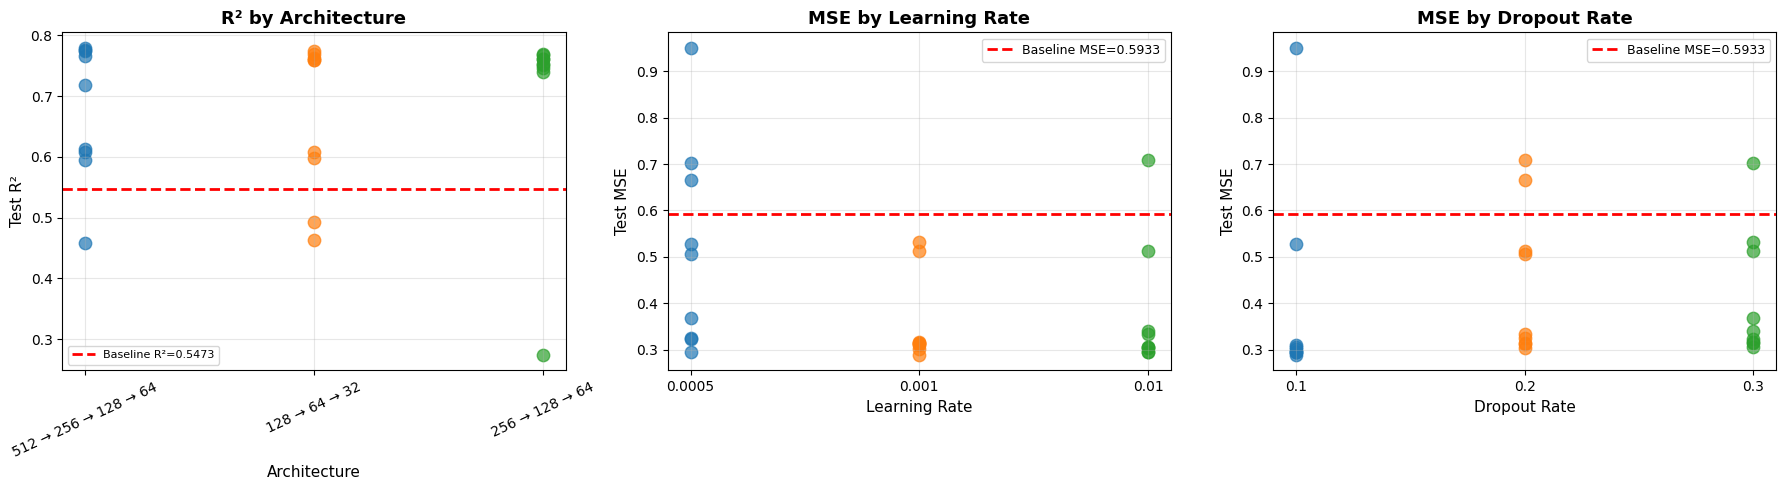

In [20]:
# Visualize HP search results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R\u00b2 by architecture
for arch in combined_df['arch'].unique():
    subset = combined_df[combined_df['arch'] == arch]
    axes[0].scatter([arch] * len(subset), subset['test_r2'], s=80, alpha=0.7)
axes[0].axhline(y=baseline_metrics['R2'], color='red', linestyle='--', linewidth=2,
                label=f'Baseline R\u00b2={baseline_metrics["R2"]:.4f}')
axes[0].set_xlabel('Architecture', fontsize=11)
axes[0].set_ylabel('Test R\u00b2', fontsize=11)
axes[0].set_title('R\u00b2 by Architecture', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# MSE by learning rate
for lr_val in sorted(combined_df['lr'].unique()):
    subset = combined_df[combined_df['lr'] == lr_val]
    axes[1].scatter([str(lr_val)] * len(subset), subset['test_mse'], s=80, alpha=0.7)
axes[1].axhline(y=baseline_metrics['MSE'], color='red', linestyle='--', linewidth=2,
                label=f'Baseline MSE={baseline_metrics["MSE"]:.4f}')
axes[1].set_xlabel('Learning Rate', fontsize=11)
axes[1].set_ylabel('Test MSE', fontsize=11)
axes[1].set_title('MSE by Learning Rate', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# MSE by dropout
for dr in sorted(combined_df['dropout'].unique()):
    subset = combined_df[combined_df['dropout'] == dr]
    axes[2].scatter([str(dr)] * len(subset), subset['test_mse'], s=80, alpha=0.7)
axes[2].axhline(y=baseline_metrics['MSE'], color='red', linestyle='--', linewidth=2,
                label=f'Baseline MSE={baseline_metrics["MSE"]:.4f}')
axes[2].set_xlabel('Dropout Rate', fontsize=11)
axes[2].set_ylabel('Test MSE', fontsize=11)
axes[2].set_title('MSE by Dropout Rate', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Final Comparison: Baseline vs Combined Improvement


     FINAL COMPARISON: Baseline vs Combined Improvement
Metric         Baseline       Combined         Change
----------------------------------------------------------------------
  MSE            0.5933         0.2885       -51.38%  ✅
  RMSE           0.7702         0.5371       -30.27%  ✅
  MAE            0.5078         0.3522       -30.65%  ✅
  R2             0.5473         0.7799       +42.51%  ✅

Baseline RMSE:  ≈ $77,024 average error
Combined RMSE:  ≈ $53,708 average error


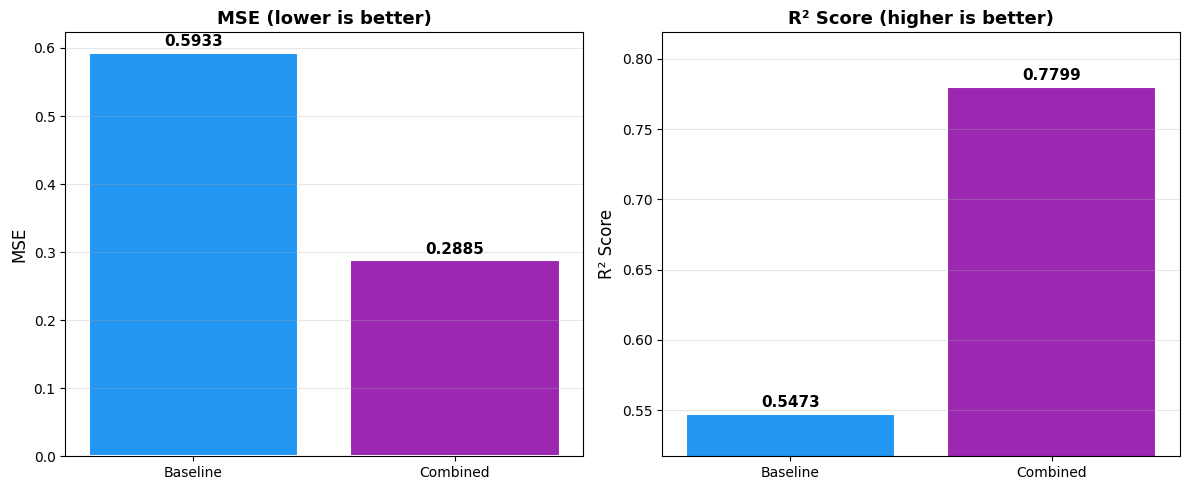

In [21]:
best_combined_metrics = {
    'MSE':  best['test_mse'],
    'RMSE': best['test_rmse'],
    'MAE':  best['test_mae'],
    'R2':   best['test_r2']
}

print('\n' + '=' * 70)
print('     FINAL COMPARISON: Baseline vs Combined Improvement')
print('=' * 70)
print(f"{'Metric':<8} {'Baseline':>14} {'Combined':>14} {'Change':>14}")
print('-' * 70)
for m in ['MSE', 'RMSE', 'MAE', 'R2']:
    b = baseline_metrics[m]
    c = best_combined_metrics[m]
    improved = (m == 'R2' and c > b) or (m != 'R2' and c < b)
    arrow = '\u2705' if improved else '\u274c'
    pct = ((c - b) / abs(b)) * 100
    print(f"  {m:<6} {b:>14.4f} {c:>14.4f} {pct:>+12.2f}%  {arrow}")
print('=' * 70)
print(f"\nBaseline RMSE:  \u2248 ${baseline_metrics['RMSE'] * 100000:,.0f} average error")
print(f"Combined RMSE:  \u2248 ${best_combined_metrics['RMSE'] * 100000:,.0f} average error")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Baseline', 'Combined']
colors = ['#2196F3', '#9C27B0']

# MSE
mse_vals = [baseline_metrics['MSE'], best_combined_metrics['MSE']]
bars = axes[0].bar(labels, mse_vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, mse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('MSE (lower is better)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# R\u00b2
r2_vals = [baseline_metrics['R2'], best_combined_metrics['R2']]
bars = axes[1].bar(labels, r2_vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('R\u00b2 Score', fontsize=12)
axes[1].set_title('R\u00b2 Score (higher is better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(bottom=min(r2_vals) - 0.03)

plt.tight_layout()
plt.show()

---
## 10. Conclusion

### Summary
- **Baseline**: A 3-layer MLP (128 → 64 → 32) trained on 8 raw features with BatchNorm, ReLU, Dropout, Adam optimizer, and early stopping.
- **Combined Improvement**: Polynomial feature engineering (8 → 44 features) + grid search over 27 configurations of learning rate, architecture, and dropout rate.

### Why the Combined Approach Works
- **Feature engineering** helps because MLPs cannot automatically discover interaction effects the way tree-based models can — providing `MedInc × AveRooms` as an explicit feature is much easier to learn than discovering it from raw inputs.
- **Hyperparameter tuning** finds the right architecture to extract maximum value from the enriched features. A model that's too small underfits the richer feature space; one that's too large overfits.
- The two techniques are **complementary**: better data gives the optimizer more signal, and the right architecture makes full use of that signal.

### Takeaways
- Always establish a solid baseline before optimising.
- Feature engineering is often the highest-ROI improvement for tabular data problems.
- Systematic hyperparameter search prevents the bias of manual trial-and-error.
- Combining data-side and model-side improvements typically outperforms either alone.